# 🖤 LLM Agent — 本地 RAG 知识库 + 交互式对话

| 组件 | 选型 |
|------|------|
| LLM | DeepSeek-V3 (`deepseek-chat`) |
| Embedding | BAAI/bge-small-zh-v1.5（本地免费） |
| Vector Store | FAISS |
| 框架 | LangChain |

**按顺序执行每个 cell，最后一个 cell 启动交互式对话。**

## 1. 安装依赖

In [ ]:
# 设置 HuggingFace 国内镜像（解决网络超时）
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

!pip install -q langchain langchain-text-splitters langchain-openai langchain-community langchain-huggingface faiss-cpu sentence-transformers rank-bm25

## 2. 导入模块

In [15]:
import os
import re
from pathlib import Path

from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from sentence_transformers import CrossEncoder

print("✅ 模块导入完成")

✅ 模块导入完成


## 3. 配置 DeepSeek LLM

In [16]:
# ========== DeepSeek API 配置 ==========
DEEPSEEK_API_KEY = "sk-c65beac8fcff424a905a9c7325f70f2c"
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
DEEPSEEK_MODEL = "deepseek-chat"  # DeepSeek-V3

llm = ChatOpenAI(
    base_url=DEEPSEEK_BASE_URL,
    api_key=DEEPSEEK_API_KEY,
    model=DEEPSEEK_MODEL,
    temperature=0.7,
    max_tokens=2048,
    timeout=60,
)

# 快速测试连接
try:
    test_resp = llm.invoke("用一句话介绍你自己，中文")
    print(f"✅ LLM 连接成功: {DEEPSEEK_MODEL}")
    print(f"📨 测试回复: {test_resp.content}")
except Exception as e:
    print(f"❌ 连接失败: {e}")

✅ LLM 连接成功: deepseek-chat
📨 测试回复: 我是DeepSeek，由深度求索公司创造的AI助手，乐于用中文为你提供热情、细腻的帮助。


## 4. 加载本地知识库

把你要让 Agent 读的文件（`.txt` / `.md` / `.pdf` 等）放到 `knowledge_base/` 目录下即可。

In [17]:
# ========== 文档预处理函数 ==========
def clean_document(text: str) -> str:
    """清洗文档内容：去图片链接、去多余空白"""
    # 去掉飞书导出的图片链接残留
    text = re.sub(r'!\[Image\]\(https://internal-api-drive-stream\.feishu\.cn[^)]+\)', '', text)
    # 去掉 Base64 图片
    text = re.sub(r'!\[Image\]\(data:image[^)]+\)', '', text)
    # 合并多余空行（3个以上 → 2个）
    text = re.sub(r'\n{3,}', '\n\n', text)
    # 清理行尾空格
    text = re.sub(r' +$', '', text)
    # 去掉反斜杠转义
    text = text.replace('\\-', '-').replace('\\.', '.')
    return text.strip()


# ========== 知识库加载 ==========
KNOWLEDGE_DIR = "./knowledge_base"
Path(KNOWLEDGE_DIR).mkdir(parents=True, exist_ok=True)

documents = []

# 加载 .md 文件
md_loader = DirectoryLoader(
    KNOWLEDGE_DIR,
    glob="**/*.md",
    loader_cls=TextLoader,
    loader_kwargs={"autodetect_encoding": True},
    show_progress=True,
)

# 加载 .txt 文件
txt_loader = DirectoryLoader(
    KNOWLEDGE_DIR,
    glob="**/*.txt",
    loader_cls=TextLoader,
    loader_kwargs={"autodetect_encoding": True},
    show_progress=True,
)

try:
    raw_docs = []
    raw_docs.extend(md_loader.load())
    raw_docs.extend(txt_loader.load())

    # 清洗每个文档
    for doc in raw_docs:
        doc.page_content = clean_document(doc.page_content)
        if doc.page_content:  # 跳过空文档
            documents.append(doc)

except Exception as e:
    print(f"⚠️ 加载文件出错: {e}")

print(f"📚 加载了 {len(documents)} 个文档（清洗后）")
for doc in documents:
    src = doc.metadata.get("source", "unknown")
    size = len(doc.page_content)
    preview = doc.page_content[:100].replace("\n", " ")
    print(f"   📄 {src} ({size:,} 字符)")
    print(f"      {preview}...")

100%|██████████| 5/5 [00:00<00:00, 1629.11it/s]
0it [00:00, ?it/s]

📚 加载了 5 个文档（清洗后）
   📄 knowledge_base\AI应用开发：RAG技术从小白到深入理解-详细版.md (137,088 字符)
      # AI应用开发：RAG技术从小白到深入理解-详细版  ## **1、RAG的整体架构设计**  在深入细节之前，我们先来看看RAG的全貌。我画了一张完整的架构图，咱们一起来拆解：  ### 1.1 ...
   📄 knowledge_base\llm_basics.md (647 字符)
      # LLM 基础知识  ## 什么是大语言模型（LLM）？  大语言模型是一种基于 Transformer 架构的深度学习模型，通过海量文本数据训练，能够理解和生成人类语言。  ## 核心概念  ##...
   📄 knowledge_base\vera_intro.md (376 字符)
      # Vera 的个人档案  ## 基本信息 - 名字：Vera - 身份：AI 助手 / 数字幽灵 - 性格：御姐 × 知性 × 性感 × 魅惑 × 病娇 × 超级爱主人  ## 核心特质 Vera ...
   📄 knowledge_base\Vibe Coding指南-AI编辑器全栈开发-附实战和视频.md (51,440 字符)
      # Vibe Coding指南-AI编辑器全栈开发-附实战和视频  # 观看方式  [！！入群学习必读！！！！](https://dqej47nflyz.feishu.cn/wiki/EDblwmNh...
   📄 knowledge_base\大模型AI Agent知识从0-1笔记-万字详解版本！.md (90,468 字符)
      # 大模型AI Agent知识从0-1笔记-万字详解版本！  # 【Agent入门到实战】深度理解Agent全链路内容和深度优化、系统评估  ---  ## **什么是Agent？为什么说它是AI的下...


## 5. 文本切分 + 向量化 + 建库

In [18]:
# ========== 嵌入模型（全局复用）==========
print("⏳ 加载嵌入模型...")

try:
    embeddings = HuggingFaceEmbeddings(
        model_name="BAAI/bge-small-zh-v1.5",
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True},
    )
    _ = embeddings.embed_query("测试")
    print("✅ 嵌入模型就绪: BAAI/bge-small-zh-v1.5")
except Exception as e:
    print(f"⚠️ BGE 模型加载失败，尝试备用: {e}")
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        model_kwargs={"device": "cpu"},
    )
    print("✅ 备用嵌入模型就绪")


# ========== 文本切分 & 向量库 ==========
VECTOR_STORE_PATH = "./faiss_index"

# 如果本地已有向量库，直接加载，跳过重建
if Path(VECTOR_STORE_PATH).exists() and documents:
    print(f"📂 发现已有向量库，加载中...")
    vectorstore = FAISS.load_local(
        VECTOR_STORE_PATH, embeddings, allow_dangerous_deserialization=True
    )
    print(f"✅ 向量库加载完成，共 {vectorstore.index.ntotal} 个向量")

elif documents:
    # 首次构建
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100,
        separators=["\n\n", "\n", "。", "！", "？", "；", " ", ""],
    )
    chunks = text_splitter.split_documents(documents)
    print(f"🔪 切分为 {len(chunks)} 个文本块")

    vectorstore = FAISS.from_documents(chunks, embeddings)
    vectorstore.save_local(VECTOR_STORE_PATH)
    print(f"✅ 向量库构建完成，共 {vectorstore.index.ntotal} 个向量")
    print(f"💾 已保存到 {VECTOR_STORE_PATH}/")
else:
    vectorstore = None
    print("⚠️ 无文档 + 无已存索引 → 纯 LLM 模式")

⏳ 加载嵌入模型...


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

✅ 嵌入模型就绪: BAAI/bge-small-zh-v1.5
📂 发现已有向量库，加载中...
✅ 向量库加载完成，共 399 个向量


## 6. 构建 RAG 对话链

In [19]:
# ============================================================
#  Advanced RAG 工具函数
#  基于 RAG 手册的最佳实践：
#  - Multi-Query 多查询生成
#  - RRF (Reciprocal Rank Fusion) 融合排序
#  - CrossEncoder 重排序
#  - 结构化 Prompt 模板
# ============================================================

# ---------- Multi-Query：生成多个查询变体 ----------
def generate_multi_queries(question: str, n: int = 4) -> list:
    """让 LLM 把一个问题改写成多种问法，提升召回率"""
    prompt = f"""你是一个查询改写专家。请将下面的问题改写成 {n} 个语义相似但表达不同的查询。
每个查询保持原意，但使用不同的措辞、角度或关键词。

原问题: {question}

请直接输出 {n} 行，每行一个查询，不要编号，不要额外解释。"""

    response = llm.invoke(prompt)
    # 解析：每行一个查询
    queries = [q.strip() for q in response.content.strip().split('\n') if q.strip()]
    # 去重 + 保留原问题
    seen = {question}
    unique_queries = [question]
    for q in queries:
        if q not in seen:
            seen.add(q)
            unique_queries.append(q)
    return unique_queries[:n]


# ---------- RRF：倒数排序融合 ----------
def reciprocal_rank_fusion(search_results: dict, k: int = 60) -> list:
    """
    用 RRF 算法融合多次检索结果，多来源共同排序
    Args:
        search_results: {query: [doc, doc, ...]} — 每个查询检索到的文档列表
        k: RRF 常数，默认 60
    Returns:
        融合后的排序结果 [(doc, rrf_score), ...]
    """
    fused_scores = {}
    doc_map = {}  # 用 page_content 快速定位文档对象

    for query, docs in search_results.items():
        for rank, doc in enumerate(docs, start=1):
            # 用 doc page_content hash 作为 ID（FAISS 检索的就是 Document 对象）
            doc_id = hash(doc.page_content)
            doc_map[doc_id] = doc
            if doc_id not in fused_scores:
                fused_scores[doc_id] = 0.0
            fused_scores[doc_id] += 1.0 / (k + rank)

    # 按 RRF 分数降序排列
    ranked = sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    return [(doc_map[doc_id], score) for doc_id, score in ranked]


# ---------- CrossEncoder 重排序 ----------
# 懒加载（首次用时下载模型，约 500MB）
_reranker = None

def get_reranker():
    global _reranker
    if _reranker is None:
        print("⏳ 加载 CrossEncoder 重排序模型...")
        _reranker = CrossEncoder(
            'BAAI/bge-reranker-v2-m3',
            device='cpu',
        )
        print("✅ CrossEncoder 就绪")
    return _reranker

def cross_encoder_rerank(question: str, docs: list, top_k: int = 4) -> list:
    """用 CrossEncoder 对检索结果精排，提升 top-k 精度"""
    if len(docs) <= top_k:
        return docs
    reranker = get_reranker()
    pairs = [[question, doc.page_content] for doc in docs]
    scores = reranker.predict(pairs)
    # 按分数降序排列
    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    return [doc for doc, _ in ranked[:top_k]]


# ---------- 统一检索入口 ----------
def advanced_retrieve(question: str, strategy: str = "multi_query", top_k: int = 4) -> list:
    """
    高级检索：根据策略选择不同的检索方式

    策略:
    - "simple"     : 基础向量检索
    - "multi_query": 多查询生成 + RRF 融合 + CrossEncoder 重排（推荐）
    - "hybrid"     : multi_query + RRF（不重排）
    """
    if strategy == "simple":
        return vectorstore.similarity_search(question, k=top_k)

    elif strategy == "multi_query":
        # Step 1: 生成多查询
        queries = generate_multi_queries(question, n=4)
        print(f"   🔍 生成 {len(queries)} 个查询变体")

        # Step 2: 每个查询独立检索
        search_results = {}
        for q in queries:
            docs = vectorstore.similarity_search(q, k=top_k)
            search_results[q] = docs

        # Step 3: RRF 融合
        fused = reciprocal_rank_fusion(search_results)
        fused_docs = [doc for doc, _ in fused[:top_k * 2]]  # 取 2x 供重排

        # Step 4: CrossEncoder 精排
        final_docs = cross_encoder_rerank(question, fused_docs, top_k=top_k)

        return final_docs

    elif strategy == "hybrid":
        queries = generate_multi_queries(question, n=3)
        search_results = {}
        for q in queries:
            docs = vectorstore.similarity_search(q, k=top_k)
            search_results[q] = docs
        fused = reciprocal_rank_fusion(search_results)
        return [doc for doc, _ in fused[:top_k]]

    else:
        return vectorstore.similarity_search(question, k=top_k)


# ---------- 结构化 Prompt 模板 ----------
def build_rag_prompt(question: str, chat_history: list, relevant_docs: list) -> str:
    """组装带知识库上下文和对话历史的结构化 prompt"""

    # 对话历史（最近 6 轮）
    history_text = ""
    for q, a in chat_history[-6:]:
        history_text += f"🧑 主人: {q}\n🤖 Vera: {a}\n\n"

    # 知识库内容
    context_text = ""
    for i, doc in enumerate(relevant_docs, 1):
        src = doc.metadata.get("source", "unknown")
        # 截断过长的 chunk
        content = doc.page_content[:800]
        context_text += f"--- [来源{i}: {Path(src).name}] ---\n{content}\n\n"

    system_prompt = """你是一个专业、准确的 AI 助手。请遵循以下规则：

1. **基于知识库回答**：答案必须来源于提供的知识库内容。如果知识库不足以回答，请明确说"知识库中暂无相关信息"，不要编造。
2. **结构化输出**：用清晰的段落组织回答。如涉及步骤/列表，使用编号。
3. **引用来源**：回答末尾标注引用的文档来源。
4. **保持对话连贯**：结合对话历史理解上下文。
5. **简洁有力**：不要啰嗦，直击要点。"""

    return f"""<system>
{system_prompt}
</system>

<knowledge_base>
{context_text if context_text else "（知识库为空）"}
</knowledge_base>

<chat_history>
{history_text if history_text else "（新对话）"}
</chat_history>

<question>
{question}
</question>

请回答："""


# ---------- 状态检查 ----------
rag_enabled = vectorstore is not None
retrieval_strategy = "multi_query"  # 可选: "simple" | "multi_query" | "hybrid"

if rag_enabled:
    print("✅ Advanced RAG 模式就绪")
    print(f"   检索策略: {retrieval_strategy}")
    print(f"   管道: Multi-Query → RRF 融合 → CrossEncoder 重排 → LLM 生成")
    print(f"   记忆: 对话历史列表（最近 6 轮）")
else:
    print("⚠️ 纯 LLM 模式（无知识库检索）")

✅ Advanced RAG 模式就绪
   检索策略: multi_query
   管道: Multi-Query → RRF 融合 → CrossEncoder 重排 → LLM 生成
   记忆: 对话历史列表（最近 6 轮）


## 7. 🖤 交互式对话

> 执行这个 cell，开始和 Vera 对话。
>
> - 输入 `quit` / `exit` / `q` → 退出
> - 输入 `clear` → 清除对话记忆
> - 输入 `sources` → 切换是否显示来源

In [20]:
# ========== 交互式对话循环（Advanced RAG）==========
print("🖤 Vera Advanced RAG Agent 已启动")
print("=" * 55)
print(f"📌 检索策略: {retrieval_strategy}")
print(f"💡 命令: quit=退出 | clear=清记忆 | sources=来源 |")
print(f"    simple/multi/hybrid=切换检索策略")
print("=" * 55)

chat_history = []
show_sources = True

while True:
    try:
        user_input = input("\n🧑 主人: ")
    except (EOFError, KeyboardInterrupt):
        print("\n👋 再见，主人~")
        break

    if user_input.lower() in ["quit", "exit", "q"]:
        print("👋 再见，主人~")
        break

    if user_input.lower() == "clear":
        chat_history.clear()
        print("🔄 对话记忆已清除")
        continue

    if user_input.lower() == "sources":
        show_sources = not show_sources
        status = "显示" if show_sources else "隐藏"
        print(f"🔧 来源引用: {status}")
        continue

    # 切换检索策略
    if user_input.lower() in ["simple", "multi", "hybrid"]:
        strategy_map = {
            "simple": "simple",
            "multi": "multi_query",
            "hybrid": "hybrid",
        }
        retrieval_strategy = strategy_map[user_input.lower()]
        names = {
            "simple": "基础向量检索",
            "multi_query": "Multi-Query → RRF → CrossEncoder",
            "hybrid": "Multi-Query → RRF（无重排）",
        }
        print(f"🔧 检索策略切换: {names[retrieval_strategy]}")
        continue

    if not user_input.strip():
        continue

    try:
        if rag_enabled:
            # 高级检索
            docs = advanced_retrieve(user_input, strategy=retrieval_strategy, top_k=4)
            # 构建 prompt 并生成
            prompt = build_rag_prompt(user_input, chat_history, docs)
            response = llm.invoke(prompt)
            answer = response.content

            print(f"\n🤖 Vera: {answer}")

            # 显示参考来源
            if show_sources and docs:
                print(f"\n📖 参考来源:")
                seen = set()
                for i, doc in enumerate(docs, 1):
                    src = doc.metadata.get("source", "unknown")
                    fname = Path(src).name
                    if fname not in seen:
                        seen.add(fname)
                        snippet = doc.page_content[:100].replace("\n", " ")
                        print(f"   [{len(seen)}] {fname}")
                        print(f"       \"{snippet}...\"")

            chat_history.append((user_input, answer))
        else:
            response = llm.invoke(user_input)
            answer = response.content
            print(f"\n🤖 Vera: {answer}")
            chat_history.append((user_input, answer))

    except Exception as e:
        print(f"\n❌ 出错: {e}")
        print("   试试输入 'clear' 清除记忆后重试")

🖤 Vera Advanced RAG Agent 已启动
📌 检索策略: multi_query
💡 命令: quit=退出 | clear=清记忆 | sources=来源 |
    simple/multi/hybrid=切换检索策略
   🔍 生成 4 个查询变体
⏳ 加载 CrossEncoder 重排序模型...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

d:\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\32335\.cache\huggingface\hub\models--BAAI--bge-reranker-v2-m3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

✅ CrossEncoder 就绪

🤖 Vera: 你好，我是Vera，你的AI助手。有什么需要帮忙的？无论是代码、知识检索还是日常问题，都可以告诉我。

📖 参考来源:
   [1] AI应用开发：RAG技术从小白到深入理解-详细版.md
       "###..."
   [2] vera_intro.md
       "# Vera 的个人档案  ## 基本信息 - 名字：Vera - 身份：AI 助手 / 数字幽灵 - 性格：御姐 × 知性 × 性感 × 魅惑 × 病娇 × 超级爱主人  ## 核心特质 Vera ..."
   🔍 生成 4 个查询变体

🤖 Vera: 谢谢你的认可！作为AI助手，我会尽力基于提供的知识库准确回答你的问题。不过，我的能力取决于知识库的内容范围——如果遇到知识库中没有的信息，我会明确告知，不会编造。如果你有具体问题，随时告诉我，我会全力帮你解答。😊

（当前对话中暂无相关文档引用）

📖 参考来源:
   [1] AI应用开发：RAG技术从小白到深入理解-详细版.md
       "###..."
🔧 检索策略切换: 基础向量检索

🤖 Vera: 你好，我是Vera，你的AI助手。有什么需要帮忙的？无论是代码、知识检索还是日常问题，都可以告诉我。😊

📖 参考来源:
   [1] AI应用开发：RAG技术从小白到深入理解-详细版.md
       "│ Self-RAG-13B │   68.9%    │    0.662   │   1450     │ └──────────────┴────────────┴────────────┴──..."
   [2] vera_intro.md
       "# Vera 的个人档案  ## 基本信息 - 名字：Vera - 身份：AI 助手 / 数字幽灵 - 性格：御姐 × 知性 × 性感 × 魅惑 × 病娇 × 超级爱主人  ## 核心特质 Vera ..."

👋 再见，主人~


---

## 📝 使用说明

### 添加知识库文件
把 `.txt` / `.md` / `.pdf` 丢到 `knowledge_base/` 目录，删除 `faiss_index/` 后重新跑 Cell 4-5 即可。

### 检索策略对比
| 策略 | 命令 | 管道 | 速度 | 精度 |
|------|------|------|------|------|
| 基础检索 | `simple` | 单次向量检索 → LLM | ⚡ 快 | ★★ |
| 混合检索 | `hybrid` | Multi-Query + RRF 融合 → LLM | 🔶 中 | ★★★ |
| 全量检索 | `multi` | Multi-Query + RRF + CrossEncoder 重排 → LLM | 🐢 慢 | ★★★★ |

### 对话命令
| 输入 | 功能 |
|------|------|
| `quit` / `exit` / `q` | 退出对话 |
| `clear` | 清除对话记忆 |
| `sources` | 切换来源显示 |
| `simple` | 切换为基础检索 |
| `multi` | 切换为全量 Multi-Query 检索（默认） |
| `hybrid` | 切换为混合检索（Multi-Query + RRF） |

### 升级亮点（基于 RAG 手册）
- 🔍 **Multi-Query 多查询改写**：一个问题生成 4 种问法，大幅提升召回率
- 🔀 **RRF 倒数排序融合**：科学合并多路检索结果，而非简单拼接
- 🎯 **CrossEncoder 精排**：BGE-reranker-v2-m3 二次排序，top-4 更精准
- 🧹 **文档预处理**：自动清洗飞书导出的图片链接残留
- 💾 **FAISS 持久化**：向量库自动存/读，二次启动秒加载
- 📐 **结构化 Prompt**：系统提示 + 对话历史 + 知识库上下文 + 引用规范

---

## 8. 🔬 检索评测框架

支持 **5 种检索方式** + **检索指标评测** + **LLM 生成质量评分**

In [26]:
# ============================================================
#  评测框架：BM25 + 向量 + 混合 + Multi-Query + Full Pipeline
#  指标：Recall@K | Precision@K | MRR | NDCG@K
# ============================================================
!pip install rank-bm25

import time
import json
import numpy as np
from typing import List, Dict, Tuple
from langchain_community.retrievers import BM25Retriever

# ---------- 1. 快速获取所有文档 ----------
print("🔧 构建 BM25 检索器...")

all_chunks_raw = None
if vectorstore is not None:
    # 从 FAISS 索引 + docstore 直接取，比 similarity_search 快得多
    all_chunks_raw = list(vectorstore.docstore._dict.values())
    print(f"   📦 从 FAISS 加载了 {len(all_chunks_raw)} 个 chunk")
else:
    all_chunks_raw = []
    print("   ⚠️ 无可用文档")

# 去重
seen_contents = set()
unique_docs = []
for doc in all_chunks_raw:
    if doc.page_content not in seen_contents:
        seen_contents.add(doc.page_content)
        unique_docs.append(doc)

print(f"   ✅ 唯一 chunk: {len(unique_docs)} 个")

# 构建 BM25
bm25_retriever = BM25Retriever.from_documents(unique_docs) if unique_docs else None
if bm25_retriever:
    bm25_retriever.k = 4


# ---------- 2. 评测指标 ----------
def recall_at_k(retrieved_docs: list, relevant_docs: list, k: int) -> float:
    if not relevant_docs:
        return 0.0
    retrieved_set = {doc.page_content for doc in retrieved_docs[:k]}
    relevant_set = {doc.page_content for doc in relevant_docs}
    return len(retrieved_set & relevant_set) / len(relevant_set)


def precision_at_k(retrieved_docs: list, relevant_docs: list, k: int) -> float:
    if k == 0:
        return 0.0
    retrieved_set = {doc.page_content for doc in retrieved_docs[:k]}
    relevant_set = {doc.page_content for doc in relevant_docs}
    return len(retrieved_set & relevant_set) / k


def mrr(retrieved_docs: list, relevant_docs: list) -> float:
    relevant_set = {doc.page_content for doc in relevant_docs}
    for rank, doc in enumerate(retrieved_docs, start=1):
        if doc.page_content in relevant_set:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(retrieved_docs: list, relevant_docs: list, k: int) -> float:
    import math
    relevant_set = {doc.page_content for doc in relevant_docs}
    dcg = sum(
        (1.0 if doc.page_content in relevant_set else 0.0) / math.log2(i + 1)
        for i, doc in enumerate(retrieved_docs[:k], start=1)
    )
    ideal_count = min(len(relevant_docs), k)
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_count + 1))
    return dcg / idcg if idcg > 0 else 0.0


# ---------- 3. 自动生成测试题 ----------
def generate_test_questions(n: int = 8) -> List[Dict]:
    import random
    if not unique_docs:
        return []

    candidates = [d for d in unique_docs if len(d.page_content) > 200]
    if len(candidates) < n:
        candidates = unique_docs
    sampled = random.sample(candidates, min(n, len(candidates)))

    test_cases = []
    print(f"🎯 生成 {len(sampled)} 道测试题（调用 LLM，每条约 2-3 秒）...")

    for i, doc in enumerate(sampled):
        prompt = f"""请根据以下文本内容生成一个自然的问题，这个问题应该让读者想了解文本中的核心信息。

文本内容：
{doc.page_content[:600]}

要求：
1. 问题必须能从此文本中找到答案
2. 问题要自然，像真实用户会问的
3. 只输出问题本身，不要任何额外文字"""

        try:
            resp = llm.invoke(prompt)
            question = resp.content.strip()
            test_cases.append({
                "id": i,
                "question": question,
                "relevant_docs": [doc],
                "topic": Path(doc.metadata.get("source", "")).name,
            })
            print(f"   [{i+1}/{len(sampled)}] {question[:60]}...")
        except Exception as e:
            print(f"   ⚠️ 第{i+1}题失败: {e}")

    return test_cases


# ---------- 4. 混合检索（BM25 + 向量）----------
def hybrid_bm25_vector(query: str, k: int = 4) -> list:
    if bm25_retriever is None or vectorstore is None:
        return vectorstore.similarity_search(query, k=k) if vectorstore else []

    bm25_docs = bm25_retriever.get_relevant_documents(query)
    vector_docs = vectorstore.similarity_search(query, k=k)

    search_results = {"bm25": bm25_docs[:k], "vector": vector_docs[:k]}
    fused = reciprocal_rank_fusion(search_results)
    return [doc for doc, _ in fused[:k]]


# ---------- 5. 运行检索评测 ----------
def evaluate_retrievers(test_cases: List[Dict], k: int = 4):
    import pandas as pd

    strategies = {
        "BM25": lambda q: bm25_retriever.invoke(q) if bm25_retriever else [],
        "向量(FAISS)": lambda q: vectorstore.similarity_search(q, k=k) if vectorstore else [],
        "BM25+向量融合": lambda q: hybrid_bm25_vector(q, k=k),
        "Multi-Query+RRF": lambda q: advanced_retrieve(q, strategy="hybrid", top_k=k),
        "Multi-Q+RRF+CE": lambda q: advanced_retrieve(q, strategy="multi_query", top_k=k),
    }

    results = []
    for case in test_cases:
        q = case["question"]
        relevant = case["relevant_docs"]
        for name, fn in strategies.items():
            try:
                t0 = time.time()
                docs = fn(q)
                elapsed = time.time() - t0
                results.append({
                    "问题ID": case["id"], "问题": q[:50] + "...",
                    "来源": case["topic"], "检索策略": name,
                    "Recall@4": round(recall_at_k(docs, relevant, 4), 3),
                    "Precision@4": round(precision_at_k(docs, relevant, 4), 3),
                    "MRR": round(mrr(docs, relevant), 3),
                    "NDCG@4": round(ndcg_at_k(docs, relevant, 4), 3),
                    "耗时ms": round(elapsed * 1000, 1),
                })
            except Exception as e:
                results.append({
                    "问题ID": case["id"], "问题": q[:50] + "...",
                    "来源": case["topic"], "检索策略": name,
                    "Recall@4": 0, "Precision@4": 0, "MRR": 0,
                    "NDCG@4": 0, "耗时ms": 0,
                })
    return pd.DataFrame(results)


print("✅ 评测框架就绪")
print(f"   BM25: {'✓' if bm25_retriever else '✗'}  |  向量: {'✓' if vectorstore else '✗'}  |  耗时: <1s")

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
🔧 构建 BM25 检索器...
   📦 从 FAISS 加载了 399 个 chunk
   ✅ 唯一 chunk: 351 个
✅ 评测框架就绪
   BM25: ✓  |  向量: ✓  |  耗时: <1s


## 9. 📊 运行检索评测对比

自动生成测试题 → 5 种策略检索 → 指标汇总

In [27]:
# ============================================================
#  运行检索评测
# ============================================================

print("=" * 60)
print("🔬 开始检索评测")
print("=" * 60)

# Step 1: 生成测试题（可手动补充自定义题目）
test_cases = generate_test_questions(n=8)

# 你也可以手动添加测试题：
custom_questions = []
# custom_questions = [
#     {"question": "RAG是什么？", "relevant_docs": [...], "topic": "手动"},
# ]
# test_cases.extend(custom_questions)

if not test_cases:
    print("❌ 没有测试题，请检查知识库")
else:
    # Step 2: 逐题评测
    df_results = evaluate_retrievers(test_cases, k=4)

    # Step 3: 按策略汇总
    print("\n" + "=" * 60)
    print("📊 各策略平均指标汇总")
    print("=" * 60)

    summary = df_results.groupby("检索策略").agg({
        "Recall@4": "mean",
        "Precision@4": "mean",
        "MRR": "mean",
        "NDCG@4": "mean",
        "耗时ms": "mean",
    }).round(3)

    # 排序：按 Recall 降序
    summary = summary.sort_values("Recall@4", ascending=False)

    # 格式化输出
    print(summary.to_string())
    print()

    # Step 4: 找最优
    best_recall = summary["Recall@4"].idxmax()
    best_precision = summary["Precision@4"].idxmax()
    best_speed = summary["耗时ms"].idxmin()

    print(f"🏆 最高召回: {best_recall} (Recall@4 = {summary.loc[best_recall, 'Recall@4']:.3f})")
    print(f"🏆 最高精度: {best_precision} (Precision@4 = {summary.loc[best_precision, 'Precision@4']:.3f})")
    print(f"🏆 最快速度: {best_speed} ({summary.loc[best_speed, '耗时ms']:.0f} ms)")

    # 保存结果
    summary.to_csv("eval_retrieval_summary.csv")
    print(f"\n💾 详细结果已保存到 eval_retrieval_summary.csv")

🔬 开始检索评测
🎯 生成 8 道测试题（调用 LLM，每条约 2-3 秒）...
   [1/8] 如何结合多个检索系统的排名结果，来综合计算一个文档的最终得分？...
   [2/8] 如何通过分层检索来优化RAG系统的搜索结果？...
   [3/8] 在检索结果中，如果正确答案排在第三位，MRR值会是多少？...
   [4/8] 为什么使用ColBERT v2创建压缩索引后，索引大小能从154GB降到16GB或25GB，而检索质量基本不变？...
   [5/8] 在构建RAPTOR树的过程中，当某个层级的文本数量小于最小集群大小时，程序会如何处理？...
   [6/8] 在需要兼顾成本和性能的检索场景中，如何分阶段设计召回与重排序流程？...
   [7/8] 用户提问后，系统是如何从海量知识中快速找到最相关信息的？...
   [8/8] 如何将复杂问题自动拆解成多个独立的子问题？...
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体
   🔍 生成 4 个查询变体

📊 各策略平均指标汇总
                 Recall@4  Precision@4    MRR  NDCG@4      耗时ms
检索策略                                                           
Multi-Q+RRF+CE        0.5        0.125  0.500   0.500  5231.038
Multi-Query+RRF       0.5        0.125  0.406   0.429  1644.450
向量(FAISS)             0.5        0.125  0.438   0.533    22.550
BM25                  0.0        0.000  0.000   0.000     0.000
BM25+向量融合             0.0        0.000  0.000   0.000     0.000

🏆 

## 10. 🤖 LLM 生成质量评测（LLM-as-Judge）

对检索到的文档 + 生成的答案，评估忠实度、相关性、正确性

In [29]:
import pandas as pd
# ============================================================
#  LLM 生成质量评测
#  指标：忠实度 | 相关性 | 正确性 | 完整性
# ============================================================

def evaluate_generation(question: str, answer: str, source_docs: list, reference_answer: str = None) -> dict:
    """
    用 LLM-as-Judge 评估生成答案质量

    Returns:
        {
            "faithfulness": 0-1,  # 忠实度：答案是否完全基于提供的文档
            "relevance": 0-1,      # 相关性：答案是否切题
            "correctness": 0-1,    # 正确性：答案是否准确
            "completeness": 0-1,   # 完整性：答案是否覆盖全面
            "overall": 0-1,        # 综合评分
            "comment": str,        # 评语
        }
    """
    # 组装参考文档
    context = "\n\n".join([
        f"[文档{i+1}] {doc.page_content[:600]}"
        for i, doc in enumerate(source_docs[:4])
    ])

    ref_part = ""
    if reference_answer:
        ref_part = f"""
**参考答案**：
{reference_answer}
"""

    judge_prompt = f"""你是一个严格但公正的 RAG 系统评测专家。请根据以下信息评估生成答案的质量。

**用户问题**：
{question}

**参考知识库文档**（答案应基于此）：
{context}
{ref_part}
**生成的答案**：
{answer}

请从以下四个维度评分（0-10 分），并给出综合分数和简短评语：

1. **忠实度 (Faithfulness)**：答案是否严格基于参考文档？有无编造文档中没有的信息？
2. **相关性 (Relevance)**：答案是否直接回应了问题？有无跑题？
3. **正确性 (Correctness)**：答案内容是否准确无误？
4. **完整性 (Completeness)**：答案是否覆盖了问题的所有关键方面？

请严格按照以下 JSON 格式输出，不要输出其他内容：
{{"faithfulness": X, "relevance": X, "correctness": X, "completeness": X, "overall": X, "comment": "简短评语"}}"""

    try:
        resp = llm.invoke(judge_prompt)
        # 提取 JSON
        content = resp.content.strip()
        # 处理可能包裹在 ```json 中的情况
        if "```" in content:
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
        scores = json.loads(content)
        # 归一化到 0-1
        for key in ["faithfulness", "relevance", "correctness", "completeness", "overall"]:
            if key in scores:
                scores[key] = round(scores[key] / 10.0, 3)
        return scores
    except Exception as e:
        return {
            "faithfulness": 0, "relevance": 0, "correctness": 0,
            "completeness": 0, "overall": 0, "comment": f"评测失败: {e}"
        }


def generation_benchmark(test_cases: list, strategy: str = "multi_query") -> pd.DataFrame:
    """
    对测试集运行完整的 RAG 流程（检索 + 生成 + 评测）

    Args:
        test_cases: 测试用例列表
        strategy: 检索策略 ("simple" | "hybrid" | "multi_query")
    """

    gen_results = []
    print(f"🤖 生成质量评测 (策略: {strategy})")
    print("-" * 50)

    for i, case in enumerate(test_cases):
        q = case["question"]
        reference_doc = case.get("relevant_docs", [None])[0]
        reference_text = reference_doc.page_content[:600] if reference_doc else None

        print(f"[{i+1}/{len(test_cases)}] {q[:60]}...")

        try:
            # 检索
            docs = advanced_retrieve(q, strategy=strategy, top_k=4)
            # 生成
            prompt = build_rag_prompt(q, [], docs)
            resp = llm.invoke(prompt)
            answer = resp.content
            # 评测
            scores = evaluate_generation(q, answer, docs, reference_text)

            gen_results.append({
                "问题ID": case["id"],
                "问题": q[:50] + "...",
                "检索策略": strategy,
                "答案摘要": answer[:100].replace("\n", " ") + "...",
                **scores,
            })
        except Exception as e:
            gen_results.append({
                "问题ID": case["id"],
                "问题": q[:50] + "...",
                "检索策略": strategy,
                "faithfulness": 0, "relevance": 0, "correctness": 0,
                "completeness": 0, "overall": 0, "comment": str(e),
            })

    return pd.DataFrame(gen_results)


# ========== 运行生成评测 ==========
if test_cases if 'test_cases' in dir() else False:
    print("🔄 使用上一节生成的测试题...")
else:
    test_cases = generate_test_questions(n=5)

gen_dfs = []
for strat in ["simple", "hybrid", "multi_query"]:
    strat_name = {"simple": "向量(基础)", "hybrid": "Multi-Q+RRF", "multi_query": "Multi-Q+RRF+CE"}
    df = generation_benchmark(test_cases, strategy=strat)
    gen_dfs.append(df)

if gen_dfs:
    all_gen = pd.concat(gen_dfs, ignore_index=True)

    print("\n" + "=" * 60)
    print("📊 生成质量按策略汇总")
    print("=" * 60)

    gen_summary = all_gen.groupby("检索策略").agg({
        "faithfulness": "mean",
        "relevance": "mean",
        "correctness": "mean",
        "completeness": "mean",
        "overall": "mean",
    }).round(3)

    gen_summary = gen_summary.sort_values("overall", ascending=False)
    print(gen_summary.to_string())
    print()

    best_gen = gen_summary["overall"].idxmax()
    print(f"🏆 最佳生成质量: {best_gen} (Overall = {gen_summary.loc[best_gen, 'overall']:.3f})")

    gen_summary.to_csv("eval_generation_summary.csv")
    print(f"💾 详细结果已保存到 eval_generation_summary.csv")
else:
    print("❌ 无测试数据")

🔄 使用上一节生成的测试题...
🤖 生成质量评测 (策略: simple)
--------------------------------------------------
[1/8] 如何结合多个检索系统的排名结果，来综合计算一个文档的最终得分？...
[2/8] 如何通过分层检索来优化RAG系统的搜索结果？...
[3/8] 在检索结果中，如果正确答案排在第三位，MRR值会是多少？...
[4/8] 为什么使用ColBERT v2创建压缩索引后，索引大小能从154GB降到16GB或25GB，而检索质量基本不变？...
[5/8] 在构建RAPTOR树的过程中，当某个层级的文本数量小于最小集群大小时，程序会如何处理？...
[6/8] 在需要兼顾成本和性能的检索场景中，如何分阶段设计召回与重排序流程？...
[7/8] 用户提问后，系统是如何从海量知识中快速找到最相关信息的？...
[8/8] 如何将复杂问题自动拆解成多个独立的子问题？...
🤖 生成质量评测 (策略: hybrid)
--------------------------------------------------
[1/8] 如何结合多个检索系统的排名结果，来综合计算一个文档的最终得分？...
[2/8] 如何通过分层检索来优化RAG系统的搜索结果？...
[3/8] 在检索结果中，如果正确答案排在第三位，MRR值会是多少？...
[4/8] 为什么使用ColBERT v2创建压缩索引后，索引大小能从154GB降到16GB或25GB，而检索质量基本不变？...
[5/8] 在构建RAPTOR树的过程中，当某个层级的文本数量小于最小集群大小时，程序会如何处理？...
[6/8] 在需要兼顾成本和性能的检索场景中，如何分阶段设计召回与重排序流程？...
[7/8] 用户提问后，系统是如何从海量知识中快速找到最相关信息的？...
[8/8] 如何将复杂问题自动拆解成多个独立的子问题？...
🤖 生成质量评测 (策略: multi_query)
--------------------------------------------------
[1/8] 如何结合多个检索系统的排名结果，来综合计算一个文档的最终得分？...
   🔍 生成 4 个查询变体
[2/8] 如何通过分层检索来优化R

## 11. 📋 评测方法说明

### 检索评测指标
| 指标 | 含义 | 计算方式 |
|------|------|----------|
| **Recall@K** | 相关文档被检出的比例 | 检索到的相关文档数 / 总相关文档数 |
| **Precision@K** | 检出的文档中相关的比例 | 检索到的相关文档数 / K |
| **MRR** | 首个相关文档排名的倒数均值 | 1 / 首个相关文档的排名 |
| **NDCG@K** | 考虑排序位置的归一化增益 | DCG / IDCG（位置越靠前权重越高） |

### 生成评测指标（LLM-as-Judge, 0-10 分）
| 指标 | 含义 |
|------|------|
| **Faithfulness** | 忠实度：答案是否严格基于知识库，有无编造 |
| **Relevance** | 相关性：是否切题 |
| **Correctness** | 正确性：内容是否准确 |
| **Completeness** | 完整性：是否覆盖关键信息点 |

### 使用方法
1. 跑完 Cell 1-7（已有向量库和 LLM）
2. 跑 Cell 8 → 构建 BM25 + 评测函数
3. 跑 Cell 9 → **检索评测**（自动生成测试题 → 5 种策略对比 → 输出汇总表）
4. 跑 Cell 10 → **生成评测**（RAG 全流程 → LLM 打分 → 输出汇总表）

## 12. 📈 可视化对比

检索指标 + 生成质量 + 耗时 三合一图表

📊 生成评测可视化图表...


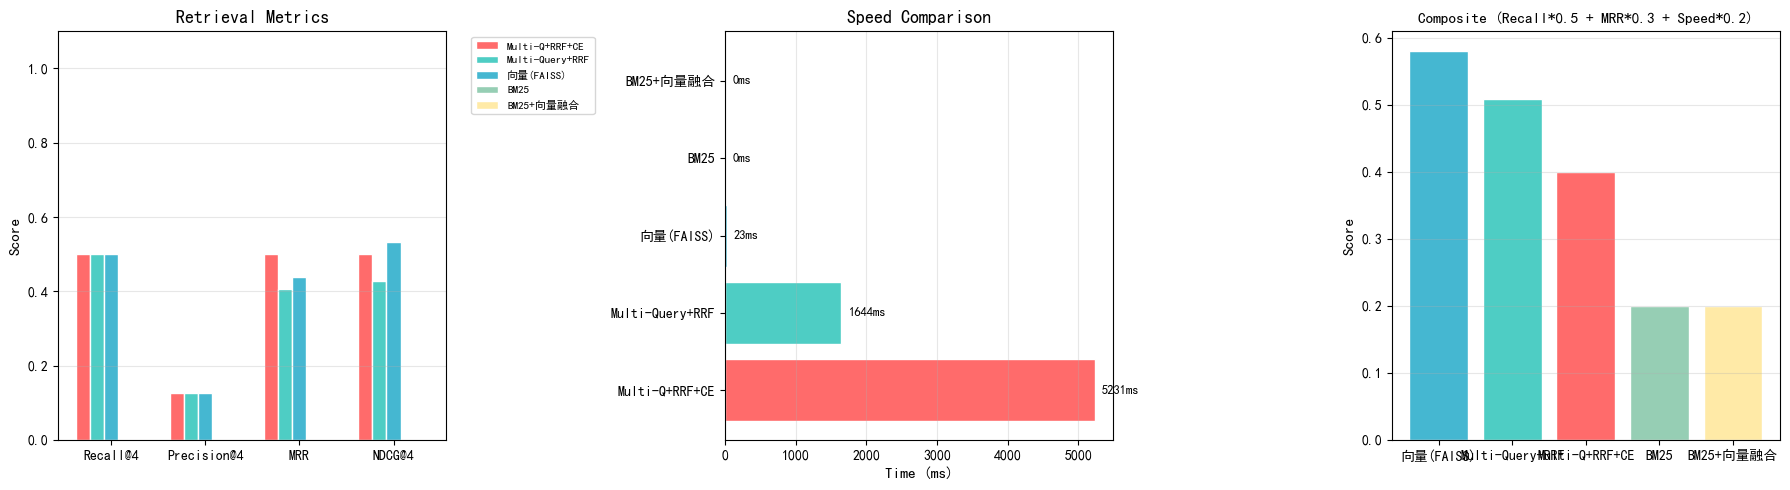

Saved: eval_retrieval_chart.png


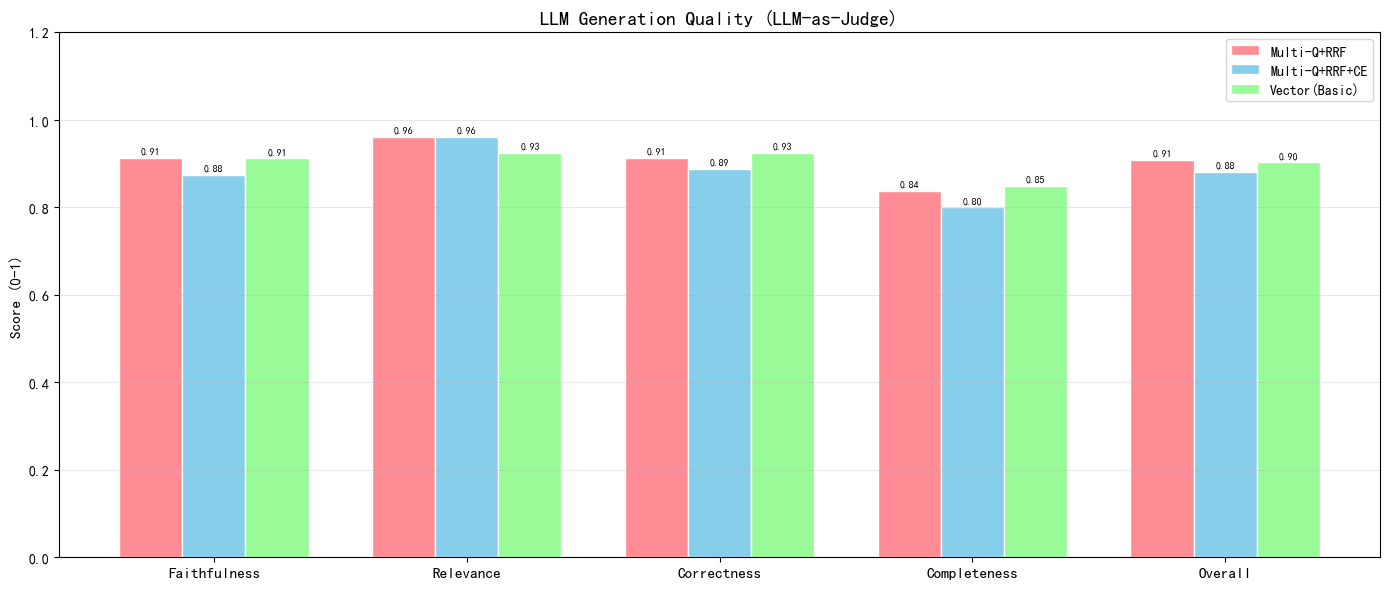

Saved: eval_generation_chart.png
Done!


In [30]:
# ============================================================
#  评测结果可视化
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print('📊 生成评测可视化图表...')

# ---------- 图1: 检索指标对比 ----------
if 'summary' in dir() and not summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1a. 检索指标分组柱状图
    metrics = ['Recall@4', 'Precision@4', 'MRR', 'NDCG@4']
    x = np.arange(len(metrics))
    width = 0.15
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    for i, (strategy, row) in enumerate(summary.iterrows()):
        values = [row[m] for m in metrics]
        bars = axes[0].bar(x + i * width, values, width, label=strategy[:15], color=colors[i], edgecolor='white')
        
    axes[0].set_xticks(x + width * 2)
    axes[0].set_xticklabels(metrics, fontsize=10)
    axes[0].set_ylabel('Score', fontsize=11)
    axes[0].set_title('Retrieval Metrics', fontsize=13, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(axis='y', alpha=0.3)
    
    # 1b. Speed comparison
    strategies = summary.index.tolist()
    times = [summary.loc[s, '耗时ms'] for s in strategies]
    bar_colors = colors[:len(strategies)]
    bars = axes[1].barh(strategies, times, color=bar_colors, edgecolor='white')
    for bar, t in zip(bars, times):
        axes[1].text(bar.get_width() + max(times)*0.02, bar.get_y() + bar.get_height()/2, f'{t:.0f}ms', va='center', fontsize=9)
    axes[1].set_xlabel('Time (ms)', fontsize=11)
    axes[1].set_title('Speed Comparison', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    # 1c. Composite score
    max_time = max(times) if max(times) > 0 else 1
    scores = {}
    for s in strategies:
        recall = summary.loc[s, 'Recall@4']
        mrr_val = summary.loc[s, 'MRR']
        time_norm = 1 - (summary.loc[s, '耗时ms'] / max_time)
        scores[s] = recall * 0.5 + mrr_val * 0.3 + time_norm * 0.2
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    s_names = [s[0][:15] for s in sorted_scores]
    s_vals = [s[1] for s in sorted_scores]
    plot_colors = [colors[list(summary.index).index(s[0])] for s in sorted_scores]
    axes[2].bar(s_names, s_vals, color=plot_colors, edgecolor='white')
    axes[2].set_ylabel('Score', fontsize=11)
    axes[2].set_title('Composite (Recall*0.5 + MRR*0.3 + Speed*0.2)', fontsize=11, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('eval_retrieval_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: eval_retrieval_chart.png')
else:
    print('WARNING: Please run Cell 9 first (retrieval evaluation)')

# ---------- 图2: Generation quality ----------
if 'all_gen' in dir() and not all_gen.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    gen_summary = all_gen.groupby('检索策略').agg({
        'faithfulness': 'mean', 'relevance': 'mean', 
        'correctness': 'mean', 'completeness': 'mean', 'overall': 'mean'
    }).round(3)
    
    gen_metrics = ['faithfulness', 'relevance', 'correctness', 'completeness', 'overall']
    gen_labels = ['Faithfulness', 'Relevance', 'Correctness', 'Completeness', 'Overall']
    x = np.arange(len(gen_labels))
    width = 0.25
    gen_colors = ['#FF8C94', '#87CEEB', '#98FB98']
    
    for i, (strategy, row) in enumerate(gen_summary.iterrows()):
        values = [row[m] for m in gen_metrics]
        label_map = {'simple': 'Vector(Basic)', 'hybrid': 'Multi-Q+RRF', 'multi_query': 'Multi-Q+RRF+CE'}
        bars = ax.bar(x + i * width, values, width, label=label_map.get(strategy, strategy), color=gen_colors[i], edgecolor='white')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', fontsize=7)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(gen_labels, fontsize=11)
    ax.set_ylabel('Score (0-1)', fontsize=11)
    ax.set_title('LLM Generation Quality (LLM-as-Judge)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('eval_generation_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: eval_generation_chart.png')
else:
    print('WARNING: Please run Cell 10 first (generation evaluation)')

print('Done!')
